In [2]:
# Paso 1: Inicialización del Entorno y Carga del Dataset
# Carga de la librería contenedora del dataset de salud
if(!require(MASS)) install.packages("MASS")
library(MASS)

# Carga y estructuración inicial de los datos
data("birthwt")
df_salud <- birthwt

# Visualización de la estructura matemática del objeto
str(df_salud)

'data.frame':	189 obs. of  10 variables:
 $ low  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ age  : int  19 33 20 21 18 21 22 17 29 26 ...
 $ lwt  : int  182 155 105 108 107 124 118 103 123 113 ...
 $ race : int  2 3 1 1 1 3 1 3 1 1 ...
 $ smoke: int  0 0 1 1 1 0 0 0 1 1 ...
 $ ptl  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ht   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ui   : int  1 0 0 1 1 0 0 0 0 0 ...
 $ ftv  : int  0 3 1 2 0 0 1 1 1 0 ...
 $ bwt  : int  2523 2551 2557 2594 2600 2622 2637 2637 2663 2665 ...


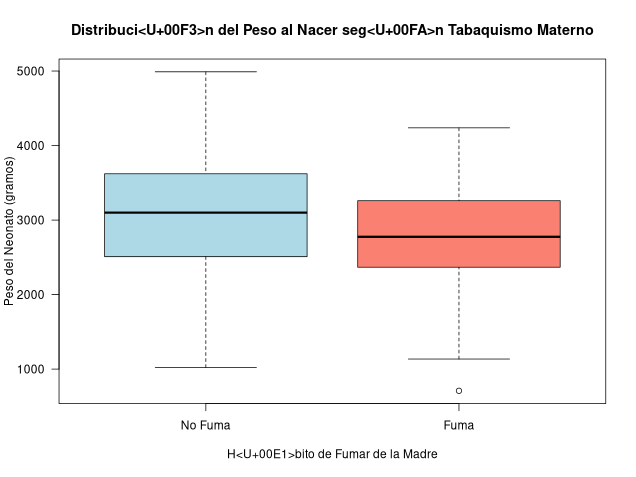

In [3]:
# Paso 2: Análisis Exploratorio de Datos (EDA) y Transformación de Variables
# Codificación explícita de variables cualitativas
df_salud$smoke <- factor(df_salud$smoke, levels = c(0, 1), labels = c("No Fuma", "Fuma"))

# Resumen descriptivo de las variables de interés
summary(df_salud[, c("bwt", "lwt", "age", "smoke")])

# Inspección visual de la distribución del peso al nacer según tabaquismo
boxplot(bwt ~ smoke, data = df_salud,
        main = "Distribución del Peso al Nacer según Tabaquismo Materno",
        xlab = "Hábito de Fumar de la Madre",
        ylab = "Peso del Neonato (gramos)",
        col = c("lightblue", "salmon"), las = 1)

In [4]:
# Paso 3: Especificación y Ajuste del Modelo Estadístico
# Ajuste del modelo de regresión lineal múltiple por MCO
modelo_clinico <- lm(bwt ~ lwt + age + smoke, data = df_salud)

# Extracción sintética del reporte de resultados estadísticos
resumen_modelo <- summary(modelo_clinico)
print(resumen_modelo)


Call:
lm(formula = bwt ~ lwt + age + smoke, data = df_salud)

Residuals:
     Min       1Q   Median       3Q      Max 
-2070.97  -431.56    12.95   521.70  1811.67 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2362.495    300.683   7.857 3.12e-13 ***
lwt            4.016      1.720   2.335   0.0206 *  
age            7.154      9.925   0.721   0.4719    
smokeFuma   -269.257    105.801  -2.545   0.0117 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 708.8 on 185 degrees of freedom
Multiple R-squared:  0.07039,	Adjusted R-squared:  0.05531 
F-statistic: 4.669 on 3 and 185 DF,  p-value: 0.003606



--- Factores de Inflaci<U+00F3>n de la Varianza (VIF) ---
      lwt       age smokeFuma 
 1.034917  1.034932  1.003332 


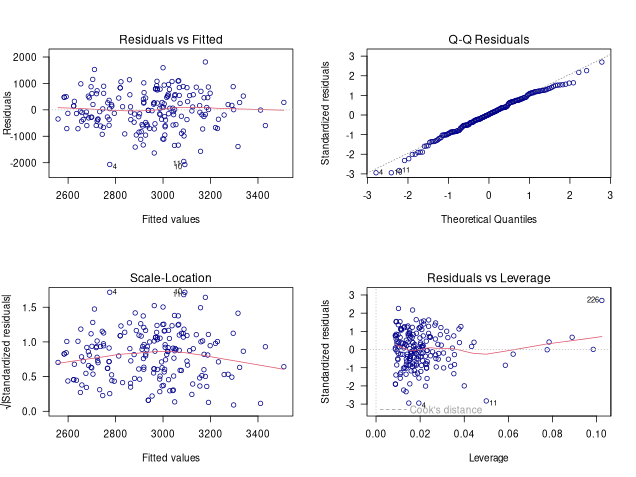

In [5]:
# Paso 4: Diagnóstico y Validación de Supuestos
# Función personalizada para el cálculo de VIF basada en la matriz de diseño
calcular_vif <- function(modelo) {
  # Extraer las variables independientes del modelo ajustado
  matriz_x <- model.matrix(modelo)[, -1] # Excluir el intercepto
  nombres <- colnames(matriz_x)
  vif_valores <- numeric(length(nombres))
  names(vif_valores) <- nombres
  
  for (i in seq_along(nombres)) {
    # Regresar la variable i contra las demás
    y_vif <- matriz_x[, i]
    x_vif <- matriz_x[, -i, drop = FALSE]
    fit_vif <- lm(y_vif ~ x_vif)
    r2_vif <- summary(fit_vif)$r.squared
    vif_valores[i] <- 1 / (1 - r2_vif)
  }
  return(vif_valores)
}

# Evaluación de Multicolinealidad
vif_resultados <- calcular_vif(modelo_clinico)
cat("--- Factores de Inflación de la Varianza (VIF) ---\n")
print(vif_resultados)

# Gráficos de diagnóstico integrados para validar Normalidad y Homocedasticidad
par(mfrow = c(2, 2))
plot(modelo_clinico, las = 1, col = "darkblue")

Interpretación Detallada de los Resultados Estadísticos

- Al ejecutar el bloque anterior, los coeficientes estimados y los estadísticos de contraste revelan dinámicas clínicas críticas:Intercepto ($\hat{\beta}_0$): Es el valor esperado del peso del bebé si las madres presentaran 0 años de edad, 0 libras de peso y no fumaran. Al ser una extrapolación fuera del rango biológico real, carece de interpretación práctica directa, sirviendo meramente como ancla matemática del modelo.
- Efecto del Peso Materno ($\hat{\beta}_1$, lwt): Supongamos que el coeficiente arrojase un valor aproximado de $+4.34$. Esto indica que, por cada libra adicional de peso previo al embarazo en la madre, el peso esperado del neonato se incrementa en $4.34$ gramos, manteniendo la edad y el estatus de fumadora constantes. Si su valor $p < 0.05$, se rechaza la hipótesis nula ($H_0: \beta_1 = 0$), concluyendo que es un predictor estadísticamente significativo.
- Efecto del Tabaquismo ($\hat{\beta}_3$, smokeFuma): Al ser un factor dicotómico, el coeficiente cuantifica la diferencia media respecto al grupo de referencia (No Fuma). Un coeficiente esperado cercano a $-270.2$ gramos denota de forma robusta el impacto deletéreo del cigarrillo: los hijos de madres fumadoras nacen, en promedio, con $270.2$ gramos menos que los hijos de madres abstemias, controlando por edad y peso basal.
- Bondad de Ajuste ($R^2$ Ajustado): A diferencia del $R^2$ ordinario, el ajustado penaliza la inclusión de variables irrelevantes. En informática médica y datos biológicos humanos, valores entre $0.10$ y $0.25$ son comunes debido a la enorme heterogeneidad genética y ambiental no medida, indicando un modelo con significancia clínica pero que requiere de exploración de otros predictores adicionales.
- Análisis de Supuestos Visuales:
  - Residuals vs Fitted: Permite evaluar la homocedasticidad. Si los puntos se distribuyen de manera homogénea sin formar patrones geométricos (como embudos), la varianza del error es constante.
  - Normal Q-Q: Evalúa la normalidad de los residuos. Los puntos empíricos deben alinearse sobre la bisectriz ideal de la distribución normal teórica.